# load the dataset

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/hotel_bookings.csv")

# Show first 5 rows
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## EDA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
print("Shape:", df.shape)

df.info()

Shape: (119390, 32)
<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal   

In [4]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [5]:
df.isnull().sum().sort_values(ascending=False)

company                           112593
agent                              16340
country                              488
children                               4
arrival_date_month                     0
arrival_date_week_number               0
hotel                                  0
is_canceled                            0
stays_in_weekend_nights                0
arrival_date_day_of_month              0
adults                                 0
stays_in_week_nights                   0
babies                                 0
meal                                   0
lead_time                              0
arrival_date_year                      0
distribution_channel                   0
market_segment                         0
previous_bookings_not_canceled         0
is_repeated_guest                      0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
previous_cancellations                 0
deposit_type    

In [6]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 31994


In [7]:
df.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

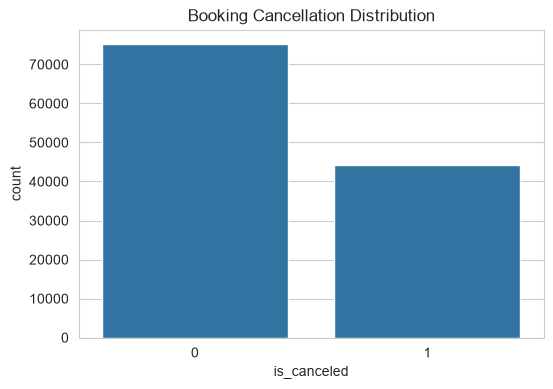

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x="is_canceled", data=df)
plt.title("Booking Cancellation Distribution")
plt.show()

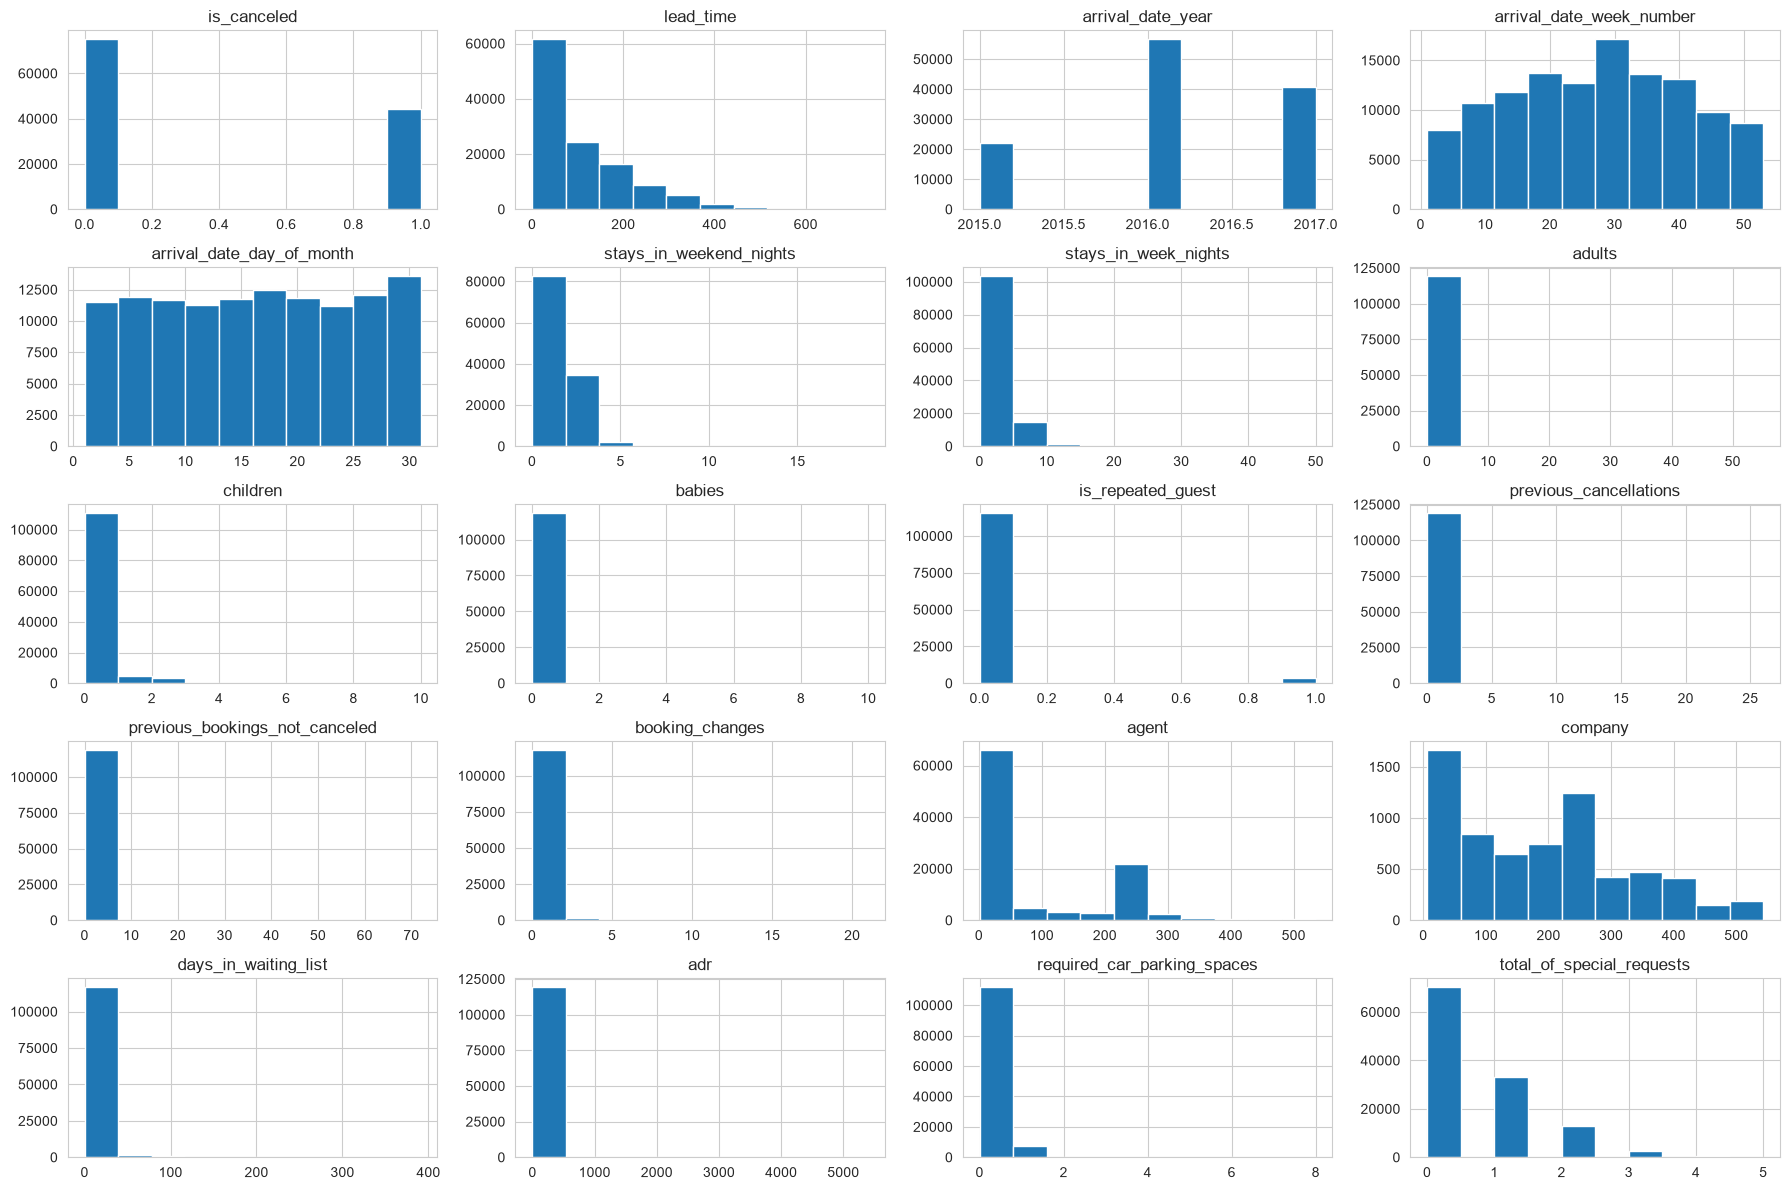

In [9]:
df.hist(figsize=(18,12))
plt.tight_layout()
plt.show()

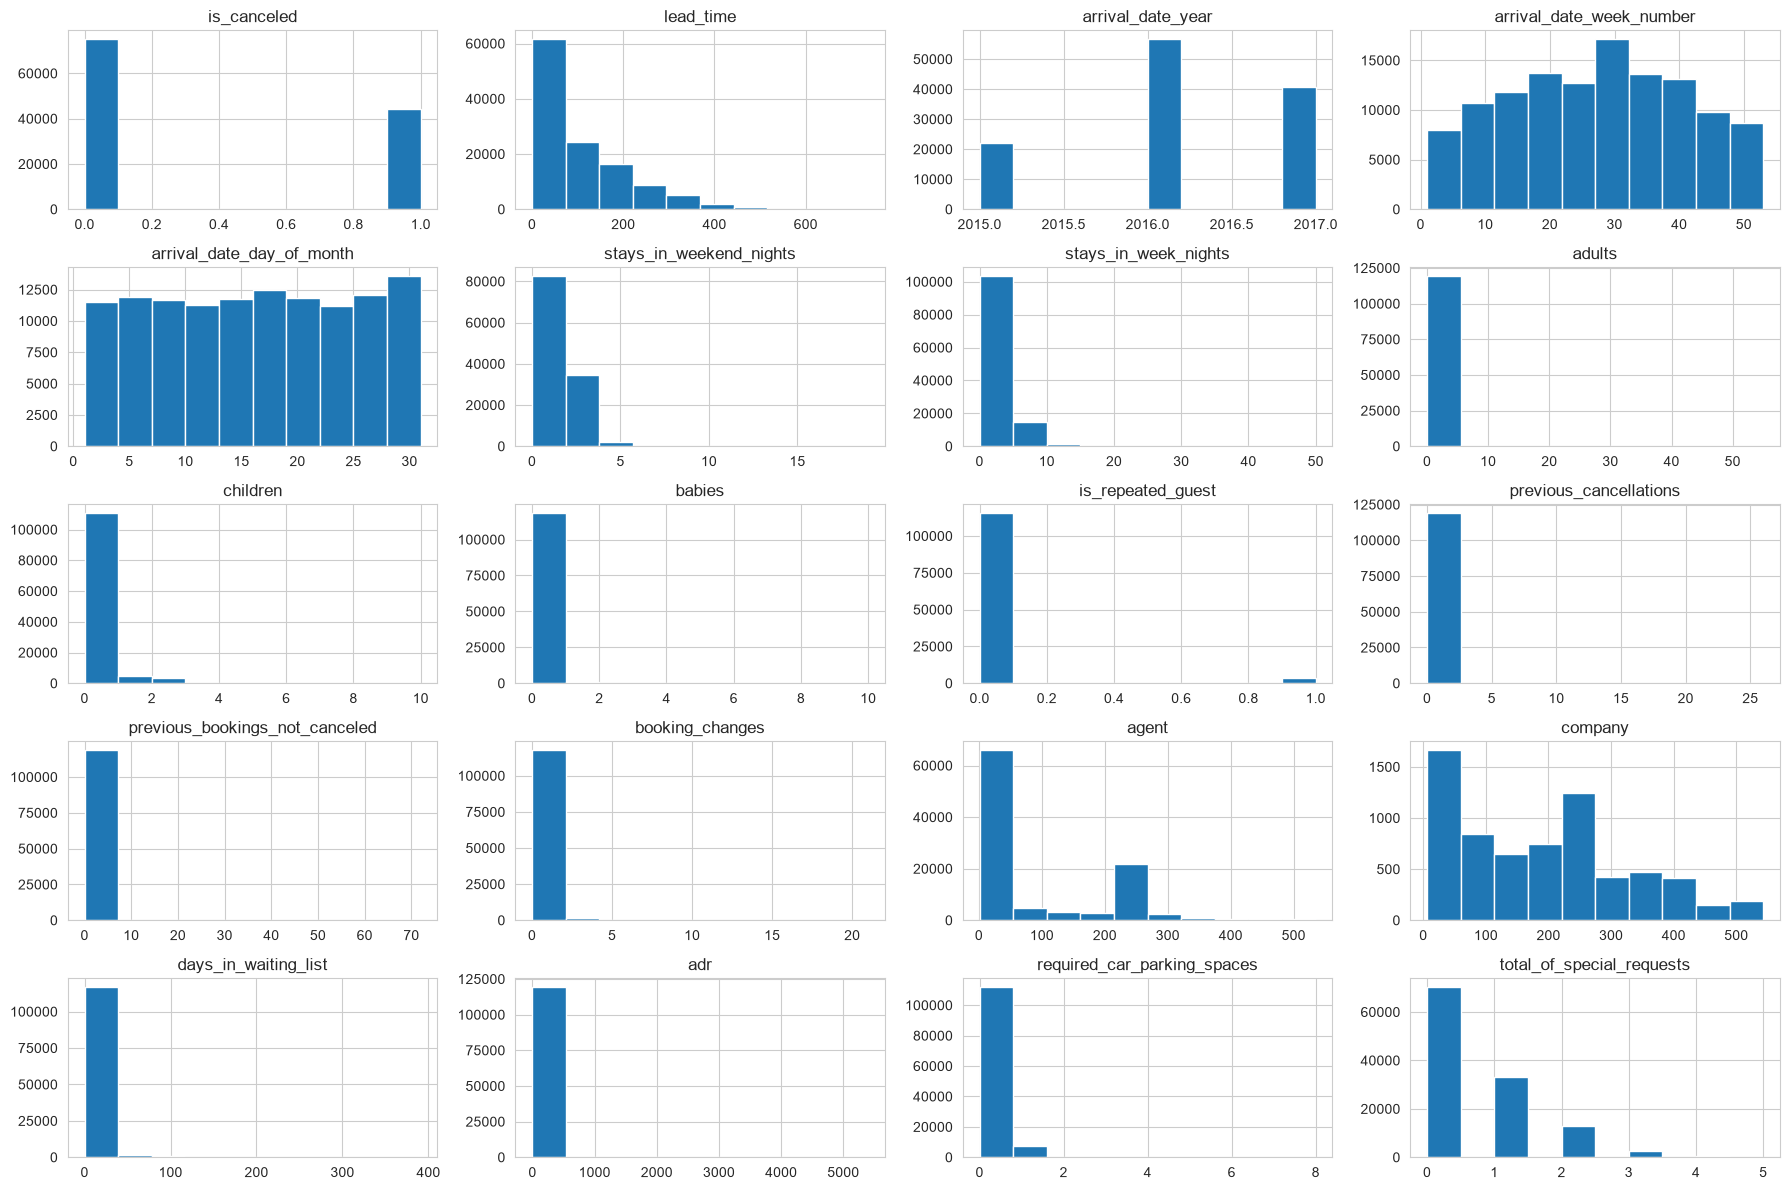

In [10]:
df.hist(figsize=(18,12))
plt.tight_layout()
plt.show()

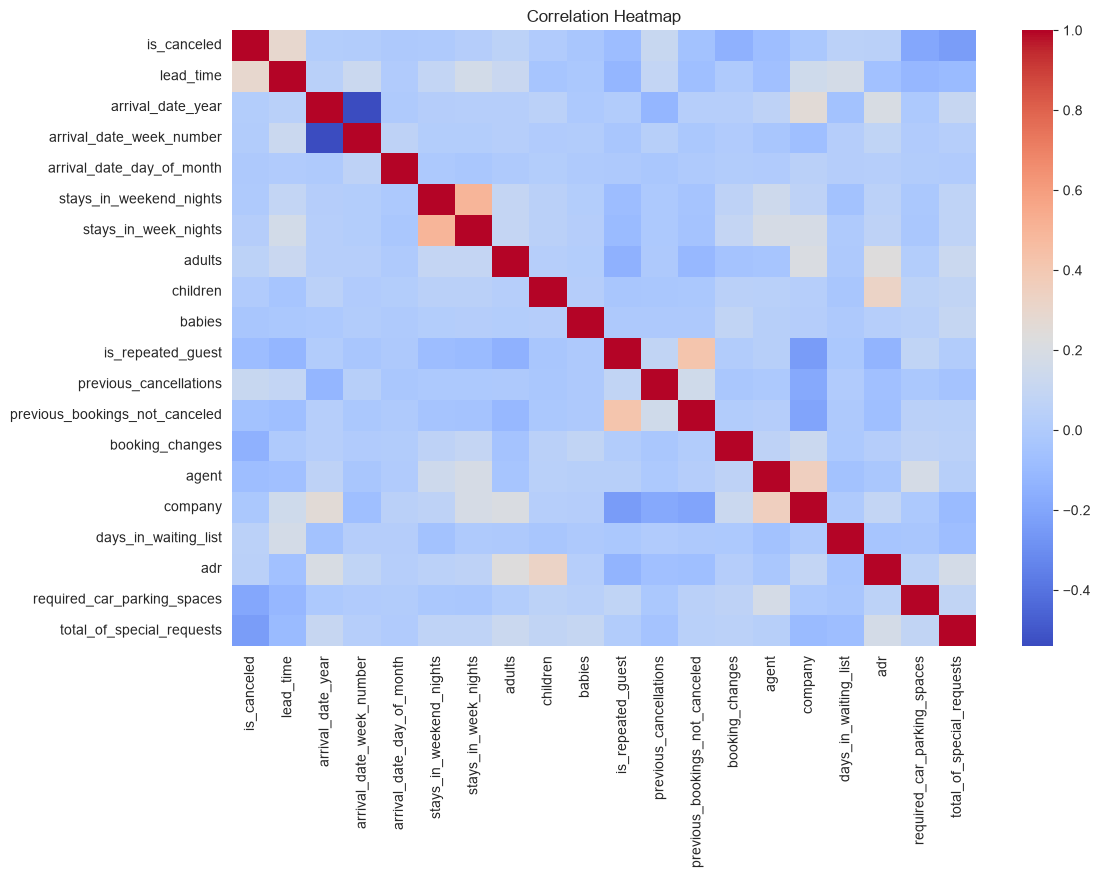

In [11]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(numeric_df.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

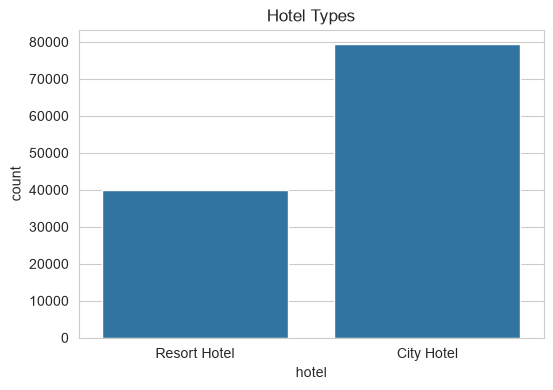

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x="hotel", data=df)
plt.title("Hotel Types")
plt.show()

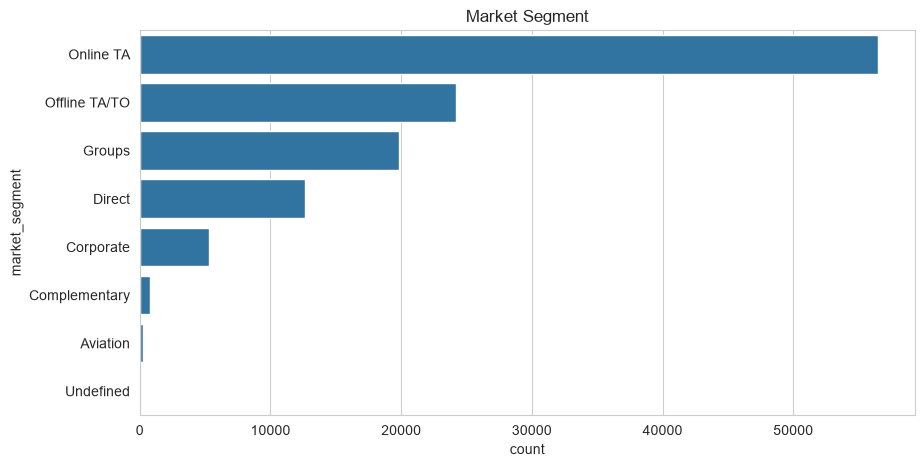

In [13]:
plt.figure(figsize=(10,5))
sns.countplot(y="market_segment", data=df, order=df["market_segment"].value_counts().index)
plt.title("Market Segment")
plt.show()

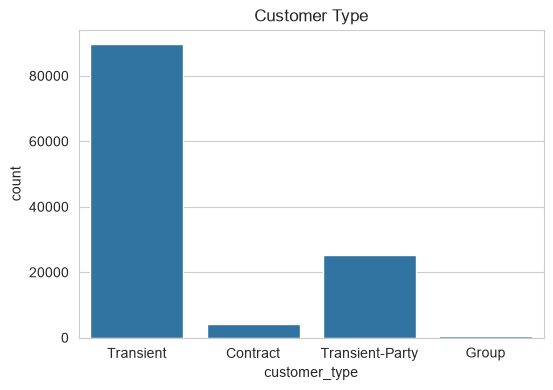

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x="customer_type", data=df)
plt.title("Customer Type")
plt.show()

In [15]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [16]:
df["children"] = df["children"].fillna(0)

df["country"] = df["country"].fillna(df["country"].mode()[0])

df["agent"] = df["agent"].fillna(0)

df["company"] = df["company"].fillna(0)

In [17]:
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

In [18]:
print("Before:", df.shape)

df = df.drop_duplicates()

print("After:", df.shape)

Before: (119390, 32)
After: (87377, 32)


In [19]:
df.to_csv("../data/hotel_bookings_clean.csv", index=False)

print("Clean dataset saved successfully!")

Clean dataset saved successfully!


In [20]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

ImportError: DLL load failed while importing _group_columns: An Application Control policy has blocked this file.

In [ ]:
categorical_columns = df.select_dtypes(include=["object"]).columns

print(categorical_columns)

C:\Users\anast\AppData\Local\Temp\ipykernel_1544\692853050.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns


Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'reservation_status',
       'reservation_status_date'],
      dtype='str')


In [ ]:
le = LabelEncoder()

for col in categorical_columns:
    df[col] = le.fit_transform(df[col].astype(str))

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,1,0,342,2015,5,27,1,0,0,2,...,0,0.0,0.0,0,2,0.0,0,0,1,121
1,1,0,737,2015,5,27,1,0,0,2,...,0,0.0,0.0,0,2,0.0,0,0,1,121
2,1,0,7,2015,5,27,1,0,1,1,...,0,0.0,0.0,0,2,75.0,0,0,1,122
3,1,0,13,2015,5,27,1,0,1,1,...,0,304.0,0.0,0,2,75.0,0,0,1,122
4,1,0,14,2015,5,27,1,0,2,2,...,0,240.0,0.0,0,2,98.0,0,1,1,123


In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 87377 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87377 non-null  int64  
 1   is_canceled                     87377 non-null  int64  
 2   lead_time                       87377 non-null  int64  
 3   arrival_date_year               87377 non-null  int64  
 4   arrival_date_month              87377 non-null  int64  
 5   arrival_date_week_number        87377 non-null  int64  
 6   arrival_date_day_of_month       87377 non-null  int64  
 7   stays_in_weekend_nights         87377 non-null  int64  
 8   stays_in_week_nights            87377 non-null  int64  
 9   adults                          87377 non-null  int64  
 10  children                        87377 non-null  float64
 11  babies                          87377 non-null  int64  
 12  meal                            87377 non-null 

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [ ]:
X = df.drop("is_canceled", axis=1)
y = df["is_canceled"]

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature scaling completed!")

Feature scaling completed!


In [ ]:
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,1.254501,3.045657,-1.763937,-0.085131,0.011694,-1.676935,-0.974258,-1.278512,0.198082,-0.304144,...,-0.111304,-0.736837,-0.203785,-0.074847,-0.105803,-1.933379,-0.299205,-0.839746,0.547286,-1.971711
1,1.254501,7.635744,-1.763937,-0.085131,0.011694,-1.676935,-0.974258,-1.278512,0.198082,-0.304144,...,-0.111304,-0.736837,-0.203785,-0.074847,-0.105803,-1.933379,-0.299205,-0.839746,0.547286,-1.971711
2,1.254501,-0.847200,-1.763937,-0.085131,0.011694,-1.676935,-0.974258,-0.791579,-1.398139,-0.304144,...,-0.111304,-0.736837,-0.203785,-0.074847,-0.105803,-0.569861,-0.299205,-0.839746,0.547286,-1.967096
3,1.254501,-0.777478,-1.763937,-0.085131,0.011694,-1.676935,-0.974258,-0.791579,-1.398139,-0.304144,...,-0.111304,2.028315,-0.203785,-0.074847,-0.105803,-0.569861,-0.299205,-0.839746,0.547286,-1.967096
4,1.254501,-0.765857,-1.763937,-0.085131,0.011694,-1.676935,-0.974258,-0.304647,0.198082,-0.304144,...,-0.111304,1.446178,-0.203785,-0.074847,-0.105803,-0.151716,-0.299205,0.362267,0.547286,-1.962481


In [ ]:
scaled_df = X_scaled.copy()

scaled_df["is_canceled"] = y.values

scaled_df.to_csv("../data/hotel_bookings_scaled.csv", index=False)

print("Scaled dataset saved successfully!")

Scaled dataset saved successfully!


In [21]:
df = pd.read_csv("../data/hotel_bookings_scaled.csv")

df.head()

,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,is_canceled
0,1.254501,3.045657,-1.763937,-0.085131,0.011694,-1.676935,-0.974258,-1.278512,0.198082,-0.304144,...,-0.736837,-0.203785,-0.074847,-0.105803,-1.933379,-0.299205,-0.839746,0.547286,-1.971711,0
1,1.254501,7.635744,-1.763937,-0.085131,0.011694,-1.676935,-0.974258,-1.278512,0.198082,-0.304144,...,-0.736837,-0.203785,-0.074847,-0.105803,-1.933379,-0.299205,-0.839746,0.547286,-1.971711,0
2,1.254501,-0.847200,-1.763937,-0.085131,0.011694,-1.676935,-0.974258,-0.791579,-1.398139,-0.304144,...,-0.736837,-0.203785,-0.074847,-0.105803,-0.569861,-0.299205,-0.839746,0.547286,-1.967096,0
3,1.254501,-0.777478,-1.763937,-0.085131,0.011694,-1.676935,-0.974258,-0.791579,-1.398139,-0.304144,...,2.028315,-0.203785,-0.074847,-0.105803,-0.569861,-0.299205,-0.839746,0.547286,-1.967096,0
4,1.254501,-0.765857,-1.763937,-0.085131,0.011694,-1.676935,-0.974258,-0.304647,0.198082,-0.304144,...,1.446178,-0.203785,-0.074847,-0.105803,-0.151716,-0.299205,0.362267,0.547286,-1.962481,0


In [24]:
X = df.drop("is_canceled", axis=1)
y = df["is_canceled"]

In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (69901, 31)
Testing Shape: (17476, 31)
